# Hydrogen population in solar atmosphere

    2022.12.31  k.i.

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

C:\Users\ichim\AppData\Local\Temp\ipykernel_55180\3009564256.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
from spectra_src.Struct import Atmosphere
from spectra_src.Util import HelpUtil
from spectra_src import Constants as Cst

In [73]:
# atmospheric models 
Zmax = 550. *1.E5   #  max height, cm
a = Atmosphere.init_VAL_('C')
ii = np.where(a.Z < Zmax)[0]
a.Z = a.Z[ii] ;  a.Nh = a.Nh[ii] ;  a.Ne = a.Ne[ii] ;  a.Te = a.Te[ii] ;  a.Vd = a.Vd[ii] ;  a.Vt = a.Vd[ii]
a.tau5 = a.tau5[ii] ;  a.column_mass = a.column_mass[ii]
a_VALC = a
a = Atmosphere.init_MALTM_()
ii = np.where(a.Z < Zmax)[0]
a.Z = a.Z[ii] ;  a.Nh = a.Nh[ii] ;  a.Ne = a.Ne[ii] ;  a.Te = a.Te[ii] ;  a.Vd = a.Vd[ii] ;  a.Vt = a.Vd[ii]
a.tau5 = a.tau5[ii] ;  a.column_mass = a.column_mass[ii]
a_MALT = a
HelpUtil.help_(a)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
AtmosphereC1D
|- model                   str                                      v: Malt-Sunsp...
|- Nh                      ndarray                              s: (27,)
|- Ne                      ndarray                              s: (27,)
|- Te                      ndarray                              s: (27,)
|- Vd                      ndarray                              s: (27,)
|- Vt                      ndarray                              s: (27,)
|- Z                       ndarray                              s: (27,)
|- tau5                    ndarray                              s: (27,)
|- column_mass             ndarray                              s: (27,)
|- is_uniform              bool                        

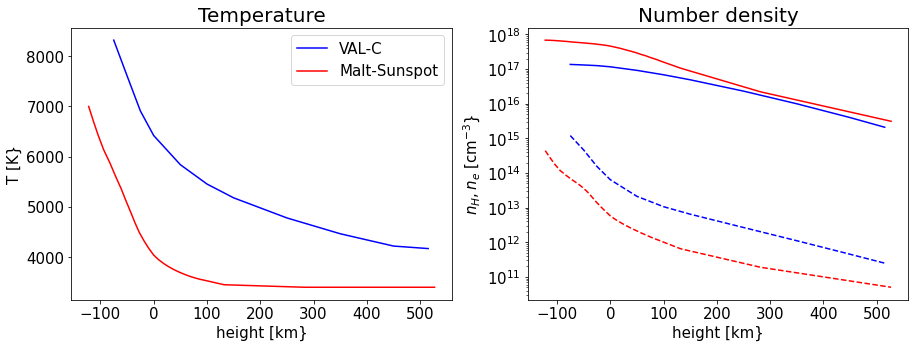

In [79]:

fig,axs = plt.subplots(1,2,figsize=[15,5])

z1 = a_VALC.Z/1e5
z2 = a_MALT.Z/1e5

ax1=axs[0]
ax1.plot(z1, a_VALC.Te[:], label=a_VALC.model,color='blue')
ax1.plot(z2, a_MALT.Te[:], label=a_MALT.model,color='red')
ax1.set_xlabel('height [km}',fontsize=15)
ax1.set_ylabel('T [K}',fontsize=15)
ax1.tick_params(labelsize=15)
ax1.set_title('Temperature',fontsize=20)
ax1.legend(fontsize=15)

ax2=axs[1]
ax2.plot(z1, a_VALC.Nh[:], label=a_VALC.model,color='blue')
ax2.plot(z1, a_VALC.Ne[:], '--',label=a_VALC.model,color='blue')
ax2.plot(z2, a_MALT.Nh[:], label=a_VALC.model,color='red')
ax2.plot(z2, a_MALT.Ne[:], '--',label=a_MALT.model,color='red')
ax2.set_yscale("log")
ax2.set_xlabel('height [km}',fontsize=15)
ax2.set_ylabel('$n_H, n_e$ [cm$^{-3}$}',fontsize=15)
ax2.tick_params(labelsize=15)
ax2.set_title('Number density',fontsize=20)


plt.show()


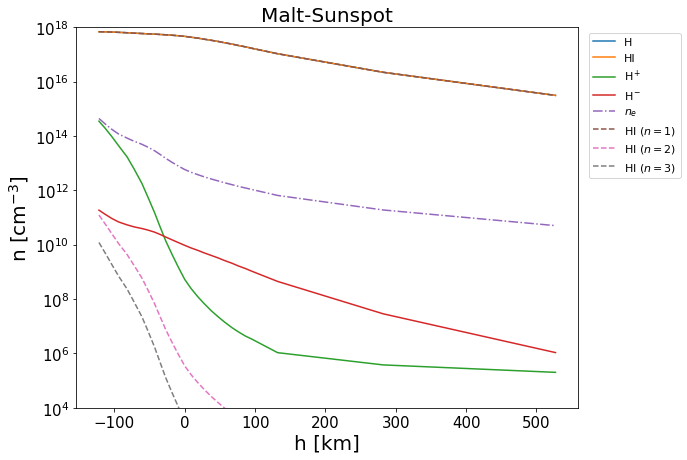

''

In [83]:
#--------------------------------------------------------------------------
# hydrogen population in LTE, by Saha-Boltzmann in reference solar atmosphere
#--------------------------------------------------------------------------
from spectra_src.Atomic import LTELib
atm = a_MALT


chi_Hm = 0.754 *Cst.eV2erg_    # binding energy of negative hydrogen [erg]
E0 = -Cst.E_Rydberg_           # ionization energy of neutral hydrogen [erg]
ns = np.array([1,2,3])     # principle quantum numbers
nn = len(ns)  # # of level n
ep = E0 *(1/ns**2 - 1)         # excitation potential [erg]
nz = len(atm.Z)

n_H = atm.Nh         # hydrogen density, [cm-3]
n_e = atm.Ne         # electron density, [cm-3],  
T = atm.Te           # temperature in K,  
h = atm.Z/1.e5       # height, [km]

kT = Cst.k_ * T
u_HI = LTELib.Ufunc_('H_I',T)      # partition func.
u_HII = LTELib.Ufunc_('H_II',T)

rmI = 1./ ( Cst.saha_ * T**(1.5) * (u_HI/1) * np.exp(-chi_Hm/kT) / n_e)    #  n_Hm/n_HI
rpI = Cst.saha_ * T**(1.5) * (u_HII/u_HI) * np.exp(E0/kT) / n_e    # n_Hp/n_HI
#  n_H = n_HI + n_Hp + n_HM = n_HI * (1 + rmI + rpI)
n_HI = n_H/(1.+rmI + rpI)
n_Hm = rmI *n_HI
n_Hp = rpI *n_HI
pHm = n_Hm/n_H
pHp = n_Hp/n_H
n_l = np.zeros([nz,nn])
for n in ns:
    gn = 2*n**2
    n_l[:,n-1] = (gn/u_HI) * np.exp(-ep[n-1]/kT) *n_HI

fig, ax = plt.subplots(1,1, figsize=(9,7)) #, dpi=150)
ax.plot(h,n_H,label="H")
ax.plot(h,n_HI,label="HI")
ax.plot(h,n_Hp,label="H$^+$")
ax.plot(h,n_Hm,label="H$^-$")
ax.plot(h,n_e,label="$n_e$",ls="-.")
for n in ns:
    ax.plot(h,n_l[:,n-1],ls="--",label="HI $(n={0:1d})$".format(n))
ax.set_xlabel("h [km]",fontsize=20)
ax.set_yscale("log")
ax.set_ylabel("n [cm$^{-3}$]",fontsize=20)
plt.tick_params(labelsize=15)
ax.set_ylim(1e4,1e18)
plt.title(atm.model,fontsize=20)
ax.legend(bbox_to_anchor=(1.01,1),fontsize=11,ncol=1)
plt.show()

;

In [48]:
n_Hm

array([6.36224296e+10, 3.00231243e+10, 1.24603589e+10, 5.89676589e+09,
       2.02665254e+09, 9.35288497e+08, 4.78826705e+08, 1.20956071e+08,
       2.72784726e+07, 5.41005464e+06, 1.63910635e+06])